# 1: Imports, Path Setup & Load Model

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
import json
import pandas as pd
import os
import pprint

import io
from PIL import ImageFilter
from keras import layers

import seaborn as sns

# Determine repo root directory (two levels up from notebooks/isabel/)
REPO_ROOT = Path.cwd().parents[1] if Path.cwd().name == "isabel" else Path.cwd()

# Path to saved Keras model inside the artifacts directory
MODEL_PATH = REPO_ROOT / "artifacts" / "gluten_guard_convnexttiny.keras"

# Directory containing test images categorized in subfolders
DATA_DIR = Path(
    "/home/isabelksommerfeld/code/lrnzgll/gluten-guard/data/"
    "food-101-predict-images-101-classes/food-101-predict-images-101-classes/"
)

# Validate that paths exist
assert MODEL_PATH.exists(), f"Model file not found at: {MODEL_PATH}"
assert DATA_DIR.exists(), f"Data directory not found at: {DATA_DIR}"

# Load trained ConvNeXt Tiny model
print(f"Loading model from: {MODEL_PATH}")
model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded successfully!")

I0000 00:00:1789400516.378025  128635 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789400517.512448  128635 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789400527.576485  128635 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Loading model from: /home/isabelksommerfeld/code/lrnzgll/gluten-guard/artifacts/gluten_guard_convnexttiny.keras


E0000 00:00:1789400534.514914  128635 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model loaded successfully!


/home/isabelksommerfeld/code/lrnzgll/gluten-guard/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'rm_sprop', because it has 184 variables whereas the saved optimizer has 369 variables. 
  saveable.load_own_variables(store)


# 2: Infer Class Names & Define Prediction Function

In [2]:
# Try to load class names from artifacts JSON if available
CLASSES_PATH = REPO_ROOT / "artifacts" / "class_names.json"

if CLASSES_PATH.exists():
    data = json.loads(CLASSES_PATH.read_text())
    class_names = data["class_names"] if isinstance(data, dict) else data
else:
    # Full list of 101 Food-101 classes in standard alphabetical order
    class_names = [
        'apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare',
        'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito',
        'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake',
        'ceviche', 'cheesecake', 'cheese_plate', 'chicken_curry', 'chicken_quesadilla',
        'chicken_wings', 'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder',
        'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame', 'cup_cakes',
        'deviled_eggs', 'donuts', 'dumplings', 'edamame', 'eggs_benedict',
        'escargots', 'falafel', 'filet_mignon', 'fish_and_chips', 'foie_gras',
        'french_fries', 'french_onion_soup', 'french_toast', 'fried_calamari', 'fried_rice',
        'frozen_yogurt', 'garlic_bread', 'gnocchi', 'greek_salad', 'grilled_cheese_sandwich',
        'grilled_salmon', 'guacamole', 'gyoza', 'hamburger', 'hot_and_sour_soup',
        'hot_dog', 'huevos_rancheros', 'hummus', 'ice_cream', 'lasagna',
        'lobster_bisque', 'lobster_roll_sandwich', 'macaroni_and_cheese', 'macarons', 'miso_soup',
        'mussels', 'nachos', 'omelette', 'onion_rings', 'oysters',
        'pad_thai', 'paella', 'pancakes', 'panna_cotta', 'peking_duck',
        'pho', 'pizza', 'pork_chop', 'poutine', 'prime_rib',
        'pulled_pork_sandwich', 'ramen', 'ravioli', 'red_velvet_cake', 'risotto',
        'samosa', 'sashimi', 'scallops', 'seaweed_salad', 'shrimp_and_grits',
        'spaghetti_bolognese', 'spaghetti_carbonara', 'spring_rolls', 'steak', 'strawberry_shortcake',
        'sushi', 'tacos', 'takoyaki', 'tiramisu', 'tuna_tartare', 'waffles'
    ]

print(f"Loaded {len(class_names)} class names.")


def predict_image_top_k(image_input, k: int = 3): ####### MODIFIED (image_path -> image_input)
    """
    Load and preprocess an image (from Path/str or PIL Image),
    then return top-k predictions across all 101 classes.
    Note: ConvNeXt Tiny model's preprocessing is built into the model, so input images
    remain in standard [0, 255] float32 scale.
    """
    # Check if input is already a PIL Image or a file path
    if isinstance(image_input, Image.Image): ####### MODIFIED
        img = image_input.convert("RGB").resize((288, 288)) ####### MODIFIED
    else:
        img = Image.open(image_input).convert("RGB").resize((288, 288)) ####### MODIFIED

    img_array = np.array(img, dtype=np.float32)
    img_batch = np.expand_dims(img_array, axis=0)  # Shape: (1, 288, 288, 3)

    probabilities = model.predict(img_batch, verbose=0)[0]

    # Sort probabilities to get top-k predicted indices
    top_indices = np.argsort(probabilities)[::-1][:k]

    results = [(class_names[idx], probabilities[idx]) for idx in top_indices]
    return img, results

Loaded 101 class names.


# 3: Full Dataset Evaluation Table (Per-Class & Overall Summary)

In [3]:
# 3: Full Dataset Evaluation Table (Per-Class & Overall Summary)
# Collect ALL test images across all subfolders
all_images = list(DATA_DIR.rglob("*.jpg")) + list(DATA_DIR.rglob("*.png"))
print(f"Evaluating all {len(all_images)} images across all class subfolders...")

results = []

for idx, img_path in enumerate(all_images):
    # Direct folder name as ground truth class (matches model class format)
    true_class = img_path.parent.name

    # Load raw image directly
    raw_img = Image.open(img_path).convert("RGB")

    # Run fast prediction on the raw image
    _, top_preds = predict_image_top_k(raw_img, k=1)
    top1_class, top1_conf = top_preds[0]

    is_correct = (top1_class == true_class)

    results.append({
        "file_name": img_path.name,
        "true_class": true_class,
        "predicted_class": top1_class,
        "correct": is_correct
    })

# Convert to DataFrame
df_results = pd.DataFrame(results)

# Group statistics by class and collect all predicted labels as a list
class_summary = (
    df_results.groupby("true_class")
    .agg(
        total_images=("correct", "count"),
        correct_predictions=("correct", "sum"),
        accuracy=("correct", "mean"),
        all_predictions=("predicted_class", list)
    )
    .reset_index()
)

# Sort classes alphabetically
class_summary = class_summary.sort_values(by="true_class", ascending=True)

# Format accuracy as percentage
class_summary["accuracy_pct"] = class_summary["accuracy"].map("{:.1%}".format)

# Calculate overall statistics
total_all = class_summary["total_images"].sum()
correct_all = class_summary["correct_predictions"].sum()
overall_acc = correct_all / total_all if total_all > 0 else 0

# Append overall summary row at the bottom
total_row = pd.DataFrame([{
    "true_class": "--- TOTAL / OVERALL ---",
    "total_images": total_all,
    "correct_predictions": correct_all,
    "accuracy": overall_acc,
    "accuracy_pct": f"{overall_acc:.1%}",
    "all_predictions": "-"
}])

final_summary = pd.concat([class_summary, total_row], ignore_index=True)

Evaluating all 383 images across all class subfolders...


I0000 00:00:1789400551.384419  128705 service.cc:153] XLA service 0x76a044a3b8e0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789400551.384564  128705 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1789400551.695261  128705 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [4]:
# Shows all rows and columns in full length
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(final_summary[["true_class", "total_images", "correct_predictions", "accuracy_pct", "all_predictions"]])

,true_class,total_images,correct_predictions,accuracy_pct,all_predictions
0,apple_pie,6,5,83.3%,"[apple_pie, apple_pie, chocolate_mousse, apple_pie, apple_pie, apple_pie]"
1,baby_back_ribs,4,4,100.0%,"[baby_back_ribs, baby_back_ribs, baby_back_ribs, baby_back_ribs]"
2,baklava,5,4,80.0%,"[baklava, baklava, baklava, baklava, chocolate_cake]"
3,beef_carpaccio,5,5,100.0%,"[beef_carpaccio, beef_carpaccio, beef_carpaccio, beef_carpaccio, beef_carpaccio]"
4,beef_tartare,5,5,100.0%,"[beef_tartare, beef_tartare, beef_tartare, beef_tartare, beef_tartare]"
5,beet_salad,4,3,75.0%,"[beet_salad, beet_salad, seaweed_salad, beet_salad]"
6,beignets,4,4,100.0%,"[beignets, beignets, beignets, beignets]"
7,bibimbap,4,4,100.0%,"[bibimbap, bibimbap, bibimbap, bibimbap]"
8,bread_pudding,4,4,100.0%,"[bread_pudding, bread_pudding, bread_pudding, bread_pudding]"
9,breakfast_burrito,4,4,100.0%,"[breakfast_burrito, breakfast_burrito, breakfast_burrito, breakfast_burrito]"


# 4: Reverse Evaluation Table (Predicted Class -> True Classes Mapping)

In [5]:
# Group predictions by the predicted label and aggregate true labels
predicted_summary = (
    df_results.groupby("predicted_class")
    .agg(
        total_predictions=("true_class", "count"),
        correct_predictions=("correct", "sum"),
        accuracy=("correct", "mean"),
        true_classes=("true_class", list)
    )
    .reset_index()
)

# Format accuracy as percentage
predicted_summary["accuracy_pct"] = predicted_summary["accuracy"].map("{:.1%}".format)

# Sort alphabetically by predicted class name
predicted_summary = predicted_summary.sort_values(by="predicted_class", ascending=True)

# Display table showing all rows
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(predicted_summary[["predicted_class", "total_predictions", "correct_predictions", "accuracy_pct", "true_classes"]])

,predicted_class,total_predictions,correct_predictions,accuracy_pct,true_classes
0,apple_pie,5,5,100.0%,"[apple_pie, apple_pie, apple_pie, apple_pie, apple_pie]"
1,baby_back_ribs,5,4,80.0%,"[pork_chop, baby_back_ribs, baby_back_ribs, baby_back_ribs, baby_back_ribs]"
2,baklava,4,4,100.0%,"[baklava, baklava, baklava, baklava]"
3,beef_carpaccio,5,5,100.0%,"[beef_carpaccio, beef_carpaccio, beef_carpaccio, beef_carpaccio, beef_carpaccio]"
4,beef_tartare,5,5,100.0%,"[beef_tartare, beef_tartare, beef_tartare, beef_tartare, beef_tartare]"
5,beet_salad,3,3,100.0%,"[beet_salad, beet_salad, beet_salad]"
6,beignets,4,4,100.0%,"[beignets, beignets, beignets, beignets]"
7,bibimbap,4,4,100.0%,"[bibimbap, bibimbap, bibimbap, bibimbap]"
8,bread_pudding,4,4,100.0%,"[bread_pudding, bread_pudding, bread_pudding, bread_pudding]"
9,breakfast_burrito,4,4,100.0%,"[breakfast_burrito, breakfast_burrito, breakfast_burrito, breakfast_burrito]"


In [6]:
# 5: Creating a database based on possible misclassifications

In [14]:
# 1. Identify confusion mappings where predicted_class != true_class
confused_mapping = (
    df_results[df_results["predicted_class"] != df_results["true_class"]]
    .groupby("predicted_class")["true_class"]
    .unique()
    .apply(list)
    .to_dict()
)

# 2. Extract all unique predicted classes from the results
all_predicted_classes = sorted(df_results["predicted_class"].unique())

# 3. Construct the dynamic dictionary
confusion_warnings = {}

for pred_class in all_predicted_classes:
    confused_list = confused_mapping.get(pred_class, [])
    has_warning = len(confused_list) > 0
    formatted_label = pred_class.replace("_", " ").capitalize()

    confusion_warnings[pred_class] = {
        "label": formatted_label,
        "celiac_risk": None,        # Placeholder for manual input
        "contains_gluten": None,     # Placeholder for manual input
        "confusion_warning": has_warning,
        "confused_with": confused_list,
        "notes": "",                 # Placeholder for manual input
        "server_questions": []       # Placeholder for manual input
    }

# 4. Save the database directly to a JSON file
with open("confusion_warnings.json", "w", encoding="utf-8") as f:
    json.dump(confusion_warnings, f, indent=4)

print("Database saved successfully as 'confusion_warnings.json'.")

Database saved successfully as 'confusion_warnings.json'.


In [17]:
# 1. Load the three JSON files
with open("celiac_db_raw.json", "r", encoding="utf-8") as f:
    celiac_raw = json.load(f)

with open("confusion_warnings.json", "r", encoding="utf-8") as f:
    confusion_base = json.load(f)

with open("confused_with.json", "r", encoding="utf-8") as f:
    confused_details = json.load(f)

# 2. Merge data into a single unified database
merged_db = {}

for dish_key, base_info in confusion_base.items():
    dish_entry = base_info.copy()

    # Merge celiac details from celiac_db_raw
    if dish_key in celiac_raw:
        raw_info = celiac_raw[dish_key]
        dish_entry["contains_gluten"] = raw_info.get("contains_gluten")
        dish_entry["celiac_risk"] = raw_info.get("celiac_risk")
        dish_entry["notes"] = raw_info.get("notes", "")
        dish_entry["server_questions"] = raw_info.get("server_questions", [])

    # Combine warning messages if multiple confused dishes exist
    confused_list = dish_entry.get("confused_with", [])

    if dish_entry.get("confusion_warning") and confused_list:
        collected_warnings = []

        for index, target_dish in enumerate(confused_list):
            lookup_key = f"confused_with_{target_dish}"

            if lookup_key in confused_details:
                warning_text = confused_details[lookup_key].get(
                    "confusion_warning", ""
                )

                if warning_text:
                    if index == 0:
                        # First warning stays as it is
                        collected_warnings.append(warning_text)
                    else:
                        # Subsequent warnings get a smooth transition phrasing
                        formatted_text = warning_text.replace(
                            "Our AI sometimes confuses this dish with",
                            "Furthermore, it can be confused with",
                        )
                        collected_warnings.append(formatted_text)

        # Join all warnings into a single string separated by spaces
        if collected_warnings:
            dish_entry["confusion_warning"] = " ".join(collected_warnings)

    merged_db[dish_key] = dish_entry

# 3. Export to a new JSON file
with open("celiac_db_merged.json", "w", encoding="utf-8") as f:
    json.dump(merged_db, f, indent=4, ensure_ascii=False)

print(
    "Successfully merged database with combined multi-confusion warnings!"
)

Successfully merged database with combined multi-confusion warnings!


In [ ]:
# 1. Target directory and file path
target_dir = "/home/isabelksommerfeld/code/lrnzgll/gluten-guard/api"
target_file_path = os.path.join(target_dir, "celiac_db.py")

# Ensure destination directory exists
os.makedirs(target_dir, exist_ok=True)

# 2. Read the merged JSON database
with open("celiac_db_merged.json", "r", encoding="utf-8") as f:
    merged_data = json.load(f)

# 3. Format as valid Python code using pprint (converts true -> True, false -> False, null -> None)
formatted_py_dict = pprint.pformat(merged_data, indent=4, sort_dicts=False)

# 4. Write to celiac_db.py
with open(target_file_path, "w", encoding="utf-8") as f:
    f.write(f"food101_celiac_db = {formatted_py_dict}\n")

print(f"Successfully created {target_file_path}")

Successfully created /home/isabelksommerfeld/code/lrnzgll/gluten-guard/api/celiac_db.py


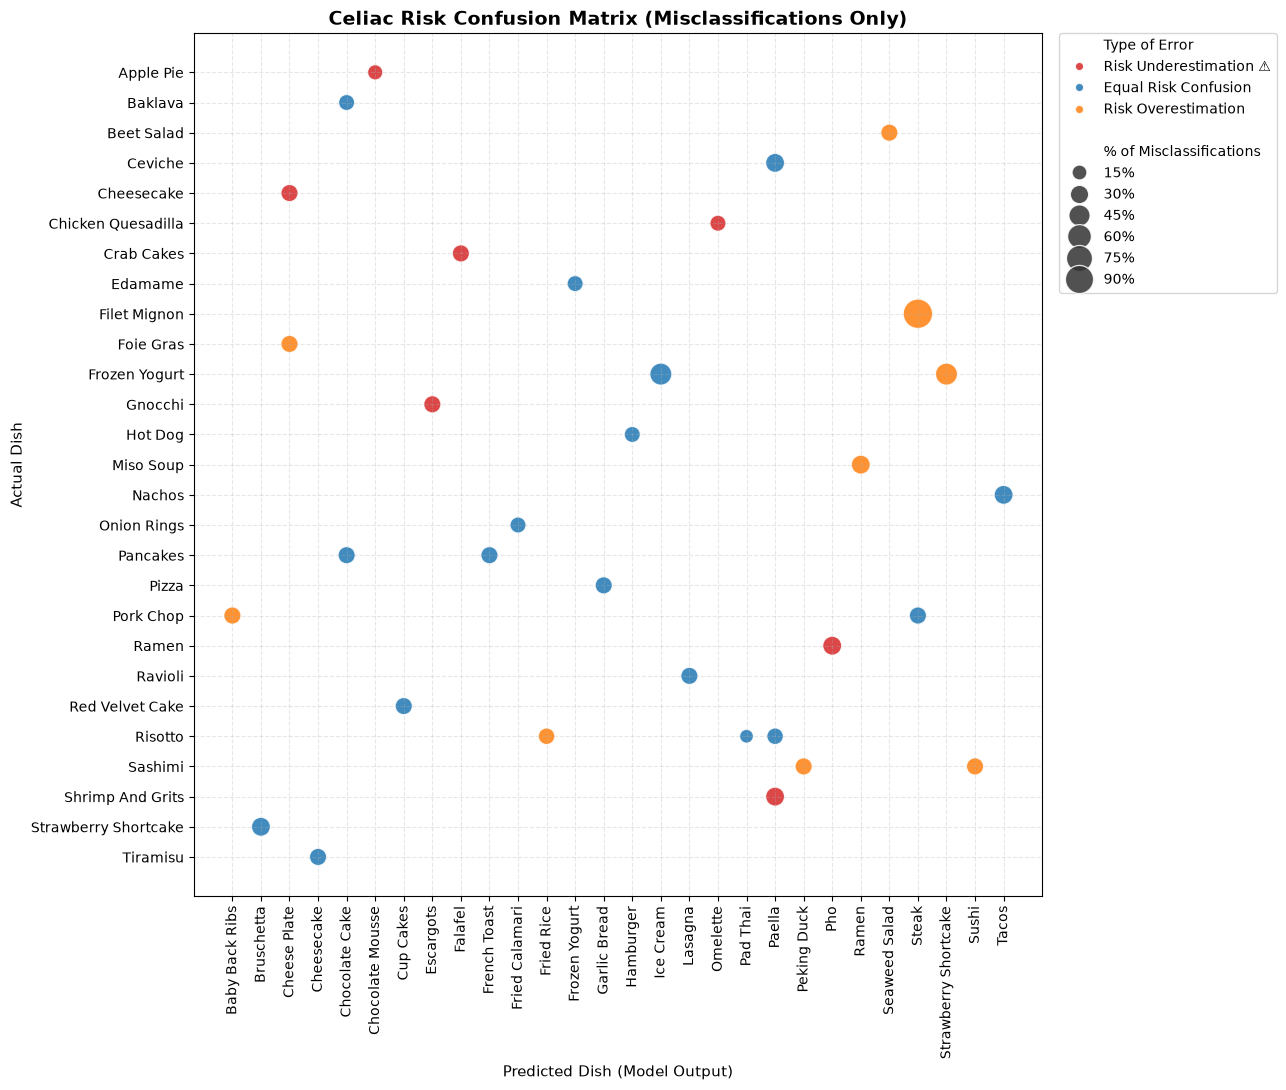

In [ ]:
# 1. Map Celiac risk levels to numeric ranks
risk_map = {"High": 3, "Medium": 2, "Low": 1, None: 0}


def get_risk(dish):
    return risk_map.get(merged_db.get(dish, {}).get("celiac_risk"), 0)


# 2. Filter errors and aggregate misclassification counts
df_errors = df_results[
    df_results["predicted_class"] != df_results["true_class"]
].copy()

error_counts = (
    df_errors.groupby(["true_class", "predicted_class"])
    .size()
    .reset_index(name="Number of Misclassifications")
)


def classify_error(row):
    t_risk, p_risk = get_risk(row["true_class"]), get_risk(row["predicted_class"])
    if p_risk < t_risk:
        return "Risk Underestimation ⚠️"
    if p_risk > t_risk:
        return "Risk Overestimation"
    return "Equal Risk Confusion"


# total number of test images per true_class (the correct denominator)
true_class_totals = df_results.groupby("true_class").size()

error_counts["% of Misclassifications"] = error_counts.apply(
    lambda row: row["Number of Misclassifications"] / true_class_totals[row["true_class"]] * 100,
    axis=1
)

error_counts["Type of Error"] = error_counts.apply(classify_error, axis=1)

error_counts["true_class_fmt"] = error_counts["true_class"].apply(lambda x: x.replace("_", " ").title())
error_counts["predicted_class_fmt"] = error_counts["predicted_class"].apply(lambda x: x.replace("_", " ").title())

all_true_classes = sorted(error_counts["true_class_fmt"].unique())
all_pred_classes = sorted(error_counts["predicted_class_fmt"].unique())

error_counts["true_class_fmt"] = pd.Categorical(error_counts["true_class_fmt"], categories=all_true_classes, ordered=True)
error_counts["predicted_class_fmt"] = pd.Categorical(error_counts["predicted_class_fmt"], categories=all_pred_classes, ordered=True)

# 3. Plot
plt.figure(figsize=(13, 11))

palette = {
    "Risk Underestimation ⚠️": "#d62728",
    "Risk Overestimation": "#ff7f0e",
    "Equal Risk Confusion": "#1f77b4",
}

ax = sns.scatterplot(
    data=error_counts,
    x="predicted_class_fmt",
    y="true_class_fmt",
    hue="Type of Error",
    size="% of Misclassifications",   # <-- was "Number of Misclassifications"
    sizes=(100, 450),
    alpha=0.85,
    palette=palette,
)

plt.xticks(rotation=90)
plt.title("Celiac Risk Confusion Matrix (Misclassifications Only)", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Dish (Model Output)", fontsize=11)
plt.ylabel("Actual Dish", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.3)

# 4. Legend cleanup + "%" formatting on the size legend
handles, labels = ax.get_legend_handles_labels()

if "% of Misclassifications" in labels:
    idx = labels.index("% of Misclassifications")
    handles.insert(idx, plt.Line2D([0], [0], color="none"))
    labels.insert(idx, "")

formatted_labels = []
for label in labels:
    try:
        val = float(label)
        formatted_labels.append(f"{val:.0f}%")
    except ValueError:
        formatted_labels.append(label)

plt.legend(handles=handles, labels=formatted_labels, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.show()

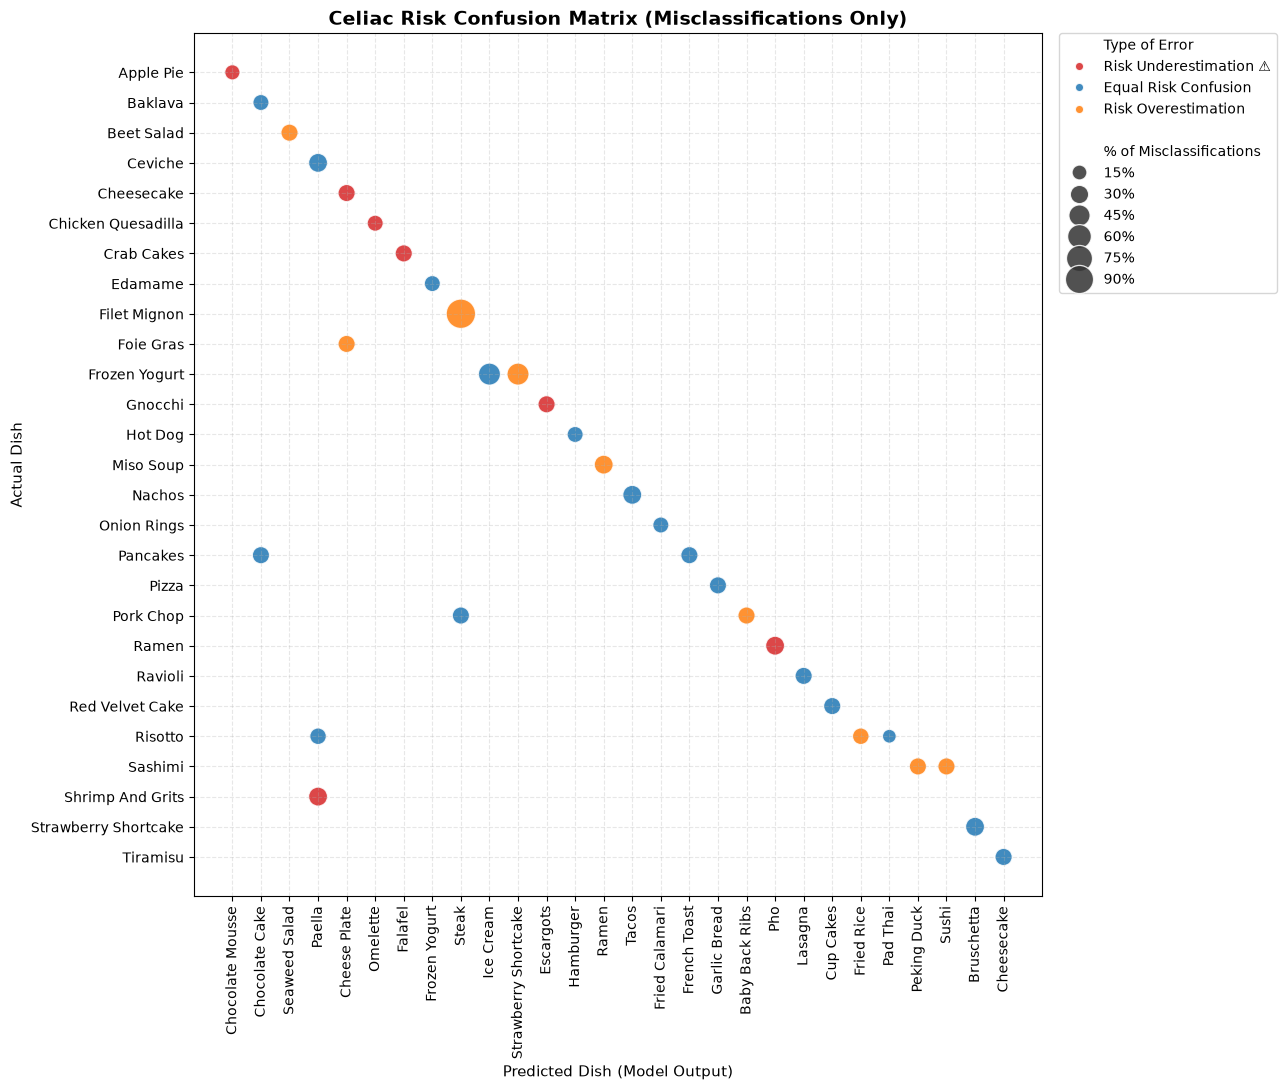

In [ ]:
# 1. Map Celiac risk levels to numeric ranks
risk_map = {"High": 3, "Medium": 2, "Low": 1, None: 0}


def get_risk(dish):
    return risk_map.get(merged_db.get(dish, {}).get("celiac_risk"), 0)


# 2. Filter errors and aggregate misclassification counts
df_errors = df_results[
    df_results["predicted_class"] != df_results["true_class"]
].copy()

error_counts = (
    df_errors.groupby(["true_class", "predicted_class"])
    .size()
    .reset_index(name="Number of Misclassifications")
)


def classify_error(row):
    t_risk, p_risk = get_risk(row["true_class"]), get_risk(
        row["predicted_class"]
    )
    if p_risk < t_risk:
        return "Risk Underestimation ⚠️"
    if p_risk > t_risk:
        return "Risk Overestimation"
    return "Equal Risk Confusion"


# Total number of test images per true_class
true_class_totals = df_results.groupby("true_class").size()

error_counts["% of Misclassifications"] = error_counts.apply(
    lambda row: row["Number of Misclassifications"]
    / true_class_totals[row["true_class"]]
    * 100,
    axis=1,
)

error_counts["Type of Error"] = error_counts.apply(classify_error, axis=1)

error_counts["true_class_fmt"] = error_counts["true_class"].apply(
    lambda x: x.replace("_", " ").title()
)
error_counts["predicted_class_fmt"] = error_counts["predicted_class"].apply(
    lambda x: x.replace("_", " ").title()
)

# 3. Plot (using default natural category ordering)
plt.figure(figsize=(13, 11))

palette = {
    "Risk Underestimation ⚠️": "#d62728",
    "Risk Overestimation": "#ff7f0e",
    "Equal Risk Confusion": "#1f77b4",
}

ax = sns.scatterplot(
    data=error_counts,
    x="predicted_class_fmt",
    y="true_class_fmt",
    hue="Type of Error",
    size="% of Misclassifications",
    sizes=(100, 450),
    alpha=0.85,
    palette=palette,
)

plt.xticks(rotation=90)
plt.title(
    "Celiac Risk Confusion Matrix (Misclassifications Only)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Predicted Dish (Model Output)", fontsize=11)
plt.ylabel("Actual Dish", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.3)

# 4. Legend cleanup + "%" formatting on the size legend
handles, labels = ax.get_legend_handles_labels()

if "% of Misclassifications" in labels:
    idx = labels.index("% of Misclassifications")
    handles.insert(idx, plt.Line2D([0], [0], color="none"))
    labels.insert(idx, "")

formatted_labels = []
for label in labels:
    try:
        val = float(label)
        formatted_labels.append(f"{val:.0f}%")
    except ValueError:
        formatted_labels.append(label)

plt.legend(
    handles=handles,
    labels=formatted_labels,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.tight_layout()
plt.show()